(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0 

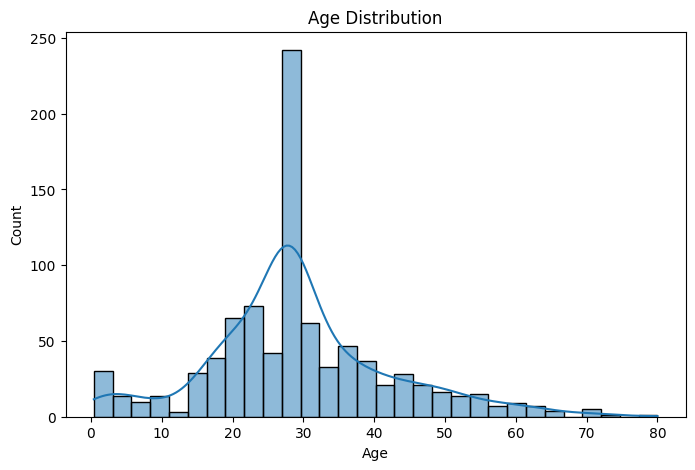

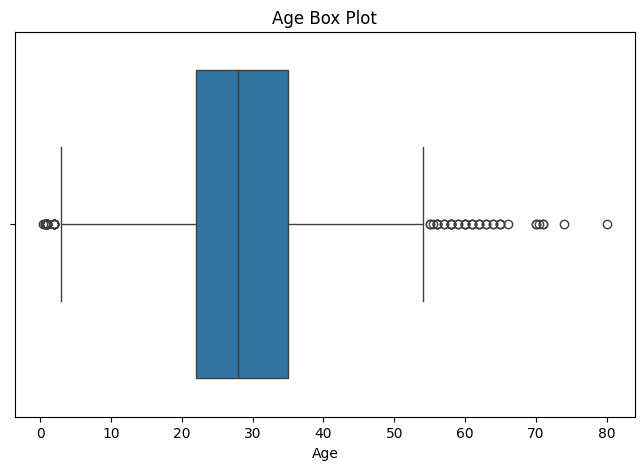

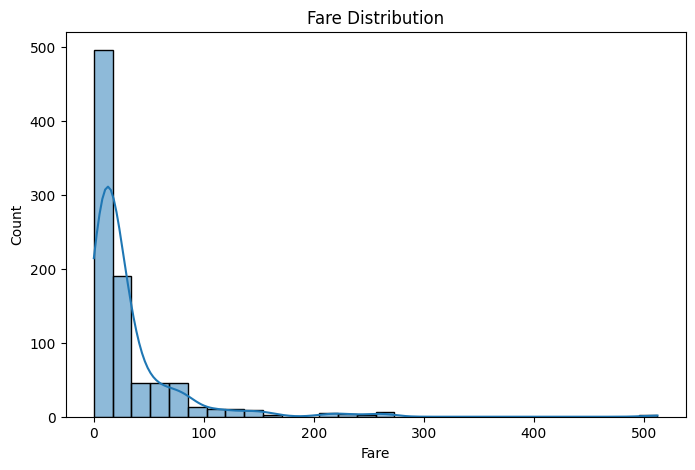

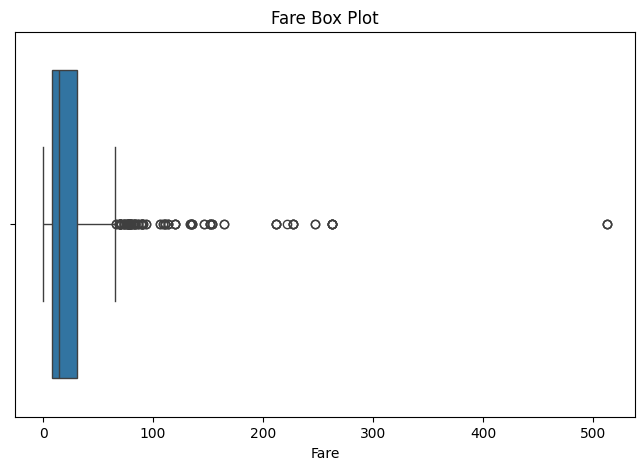

age
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower limit: 2.5
Upper limit: 54.5
Number of outliers: 65

fare
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower limit: -26.7605
Upper limit: 65.6563
Number of outliers: 114

Fare mean: 32.09668087739032
Fare median: 14.4542
Fare mode: 8.05
Survival rate by sex:
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

Survival rate by pclass:
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64
Female, 1st class: 0.967391304347826
Female, 2nd class: 0.9210526315789473
Female, 3rd class: 0.5
Male, 1st class: 0.36885245901639346
Male, 2nd class: 0.1574074074074074
Male, 3rd class: 0.13544668587896252
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.

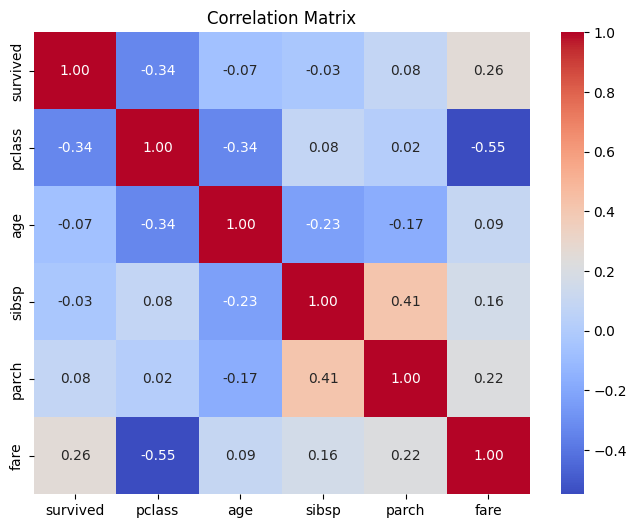

Two strongest correlations:
pclass  fare     0.548193
sibsp   parch    0.414542
dtype: float64


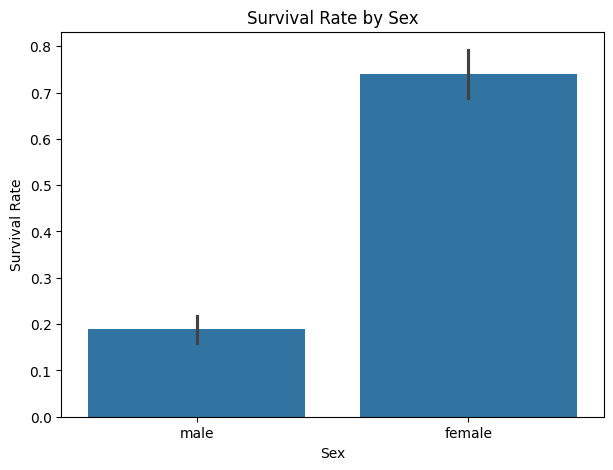

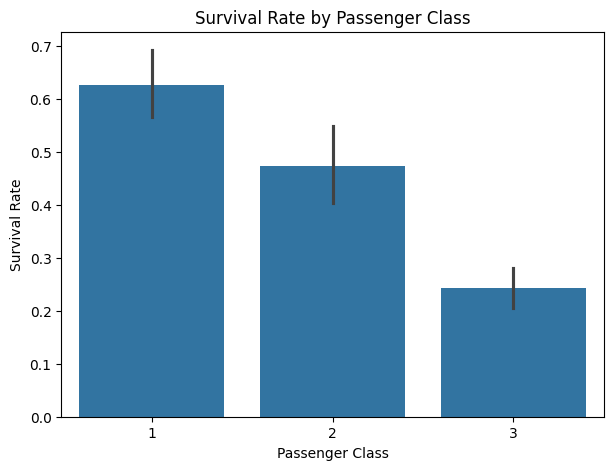

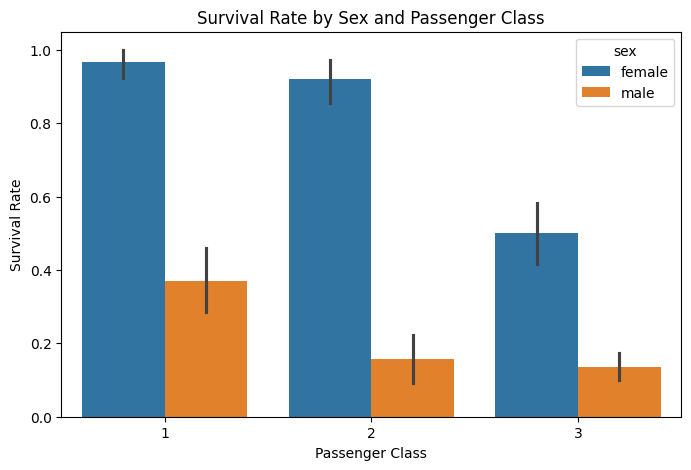

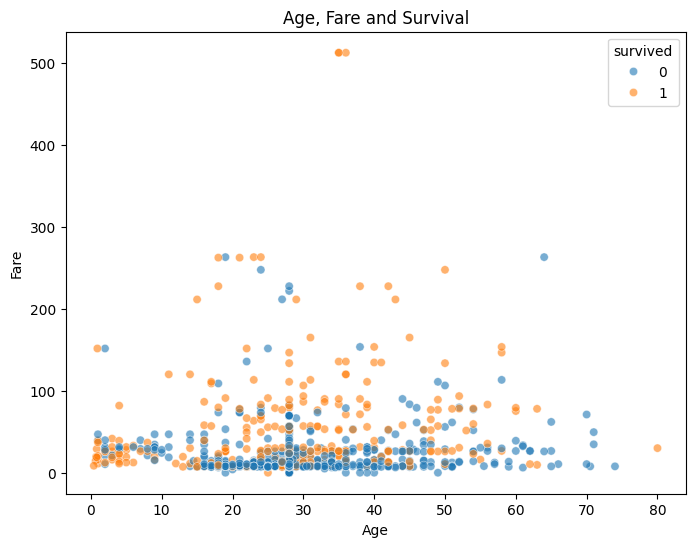

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After standardization:
      age_standardized  fare_standardized
mean      2.717486e-16       1.398706e-16
std       1.000563e+00       1.000563e+00


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

df.to_csv("titanic.csv", index=False)

print(df.shape)
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Percentage:")
print(df.isnull().mean() * 100)
print("Before cleaning:", df.shape)

df = df.dropna(subset=["embarked", "embark_town"])
df["age"] = df["age"].fillna(df["age"].median())
df = df.drop(columns=["deck"])

print("After cleaning:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

df.to_csv("titanic.csv", index=False)
print("Cleaned titanic.csv saved")

plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["age"])
plt.title("Age Box Plot")
plt.xlabel("Age")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["fare"])
plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.show()

def find_outliers(data, column):

    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    print(column)
    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)
    print("Lower limit:", lower)
    print("Upper limit:", upper)
    print("Number of outliers:", len(outliers))
    print()

find_outliers(df, "age")
find_outliers(df, "fare")

mean_fare = df["fare"].mean()
median_fare = df["fare"].median()
mode_fare = df["fare"].mode()[0]

print("Fare mean:", mean_fare)
print("Fare median:", median_fare)
print("Fare mode:", mode_fare)

survival_sex = df.groupby("sex")["survived"].mean()
print("Survival rate by sex:")
print(survival_sex)

survival_class = df.groupby("pclass")["survived"].mean()
print("\nSurvival rate by pclass:")
print(survival_class)

female_first = df[(df["sex"] == "female") & (df["pclass"] == 1)]["survived"].mean()
female_second = df[(df["sex"] == "female") & (df["pclass"] == 2)]["survived"].mean()
female_third = df[(df["sex"] == "female") & (df["pclass"] == 3)]["survived"].mean()

male_first = df[(df["sex"] == "male") & (df["pclass"] == 1)]["survived"].mean()
male_second = df[(df["sex"] == "male") & (df["pclass"] == 2)]["survived"].mean()
male_third = df[(df["sex"] == "male") & (df["pclass"] == 3)]["survived"].mean()

print("Female, 1st class:", female_first)
print("Female, 2nd class:", female_second)
print("Female, 3rd class:", female_third)
print("Male, 1st class:", male_first)
print("Male, 2nd class:", male_second)
print("Male, 3rd class:", male_third)

corr_columns = ["survived","pclass","age","sibsp","parch","fare"]
corr = df[corr_columns].corr()
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

corr_pairs = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strongest = corr_pairs.stack().sort_values(ascending=False)
print("Two strongest correlations:")
print(strongest.head(2))

plt.figure(figsize=(7, 5))
sns.barplot(data=df,x="sex",y="survived")
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.xlabel("Sex")
plt.show()

plt.figure(figsize=(7, 5))
sns.barplot(data=df,x="pclass",y="survived")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=df,x="pclass",y="survived",hue="sex")
plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df,x="age",y="fare",hue="survived",alpha=0.6)
plt.title("Age, Fare and Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df["age_standardized"] = scaler.fit_transform(df[["age"]])
df["fare_standardized"] = scaler.fit_transform(df[["fare"]])
print("Before standardization:")
print(df[["age", "fare"]].agg(["mean", "std"]))
print("\nAfter standardization:")
print(df[["age_standardized", "fare_standardized"]].agg(["mean", "std"]))

Training data: (711, 7)
Testing data: (178, 7)

Training class percentage:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing class percentage:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64
Preprocessor created successfully.
Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.

 Logistic Regression
Confusion Matrix:
[[97 13]
 [21 47]]

 Decision Tree
Confusion Matrix:
[[88 22]
 [19 49]]

 Random Forest
Confusion Matrix:
[[96 14]
 [18 50]]

Model Comparison:
                 Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.808989   0.783333  0.691176  0.734375  0.860963
1        Decision Tree  0.769663   0.690141  0.720588  0.705036  0.754144
2        Random Forest  0.820225   0.781250  0.735294  0.757576  0.817914


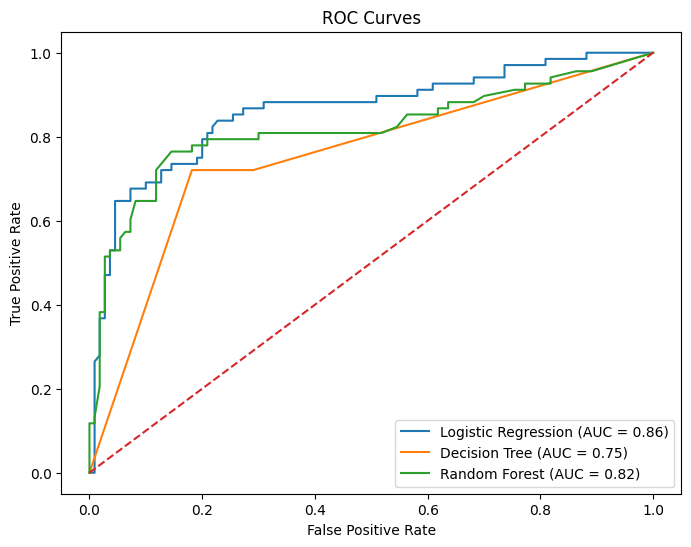

Baseline:
Precision: 0.7833333333333333
Recall: 0.6911764705882353
F1: 0.734375

Class Weight Balanced:
Precision: 0.7183098591549296
Recall: 0.75
F1: 0.7338129496402878

SMOTE:
Precision: 0.7352941176470589
Recall: 0.7352941176470589
F1: 0.7352941176470589
Best parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 200}

Best CV score:
0.7408312771917277
OOB Score: 0.8213783403656821
MAE: 18.373542111094515
RMSE: 41.29212412518077
R²: 0.3609162222350881
Adjusted R²: 0.25580375878691175


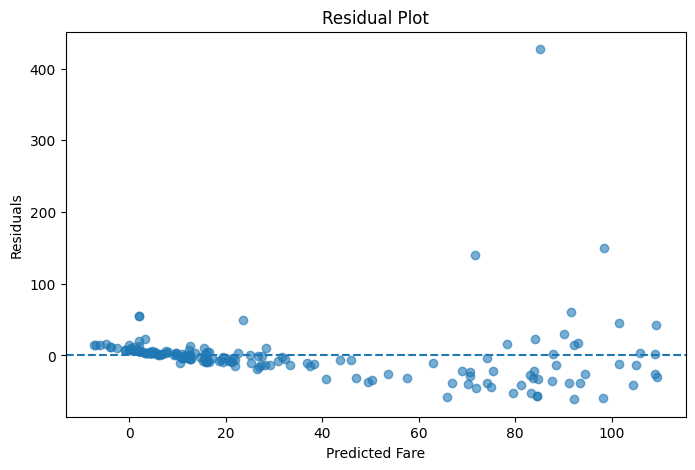

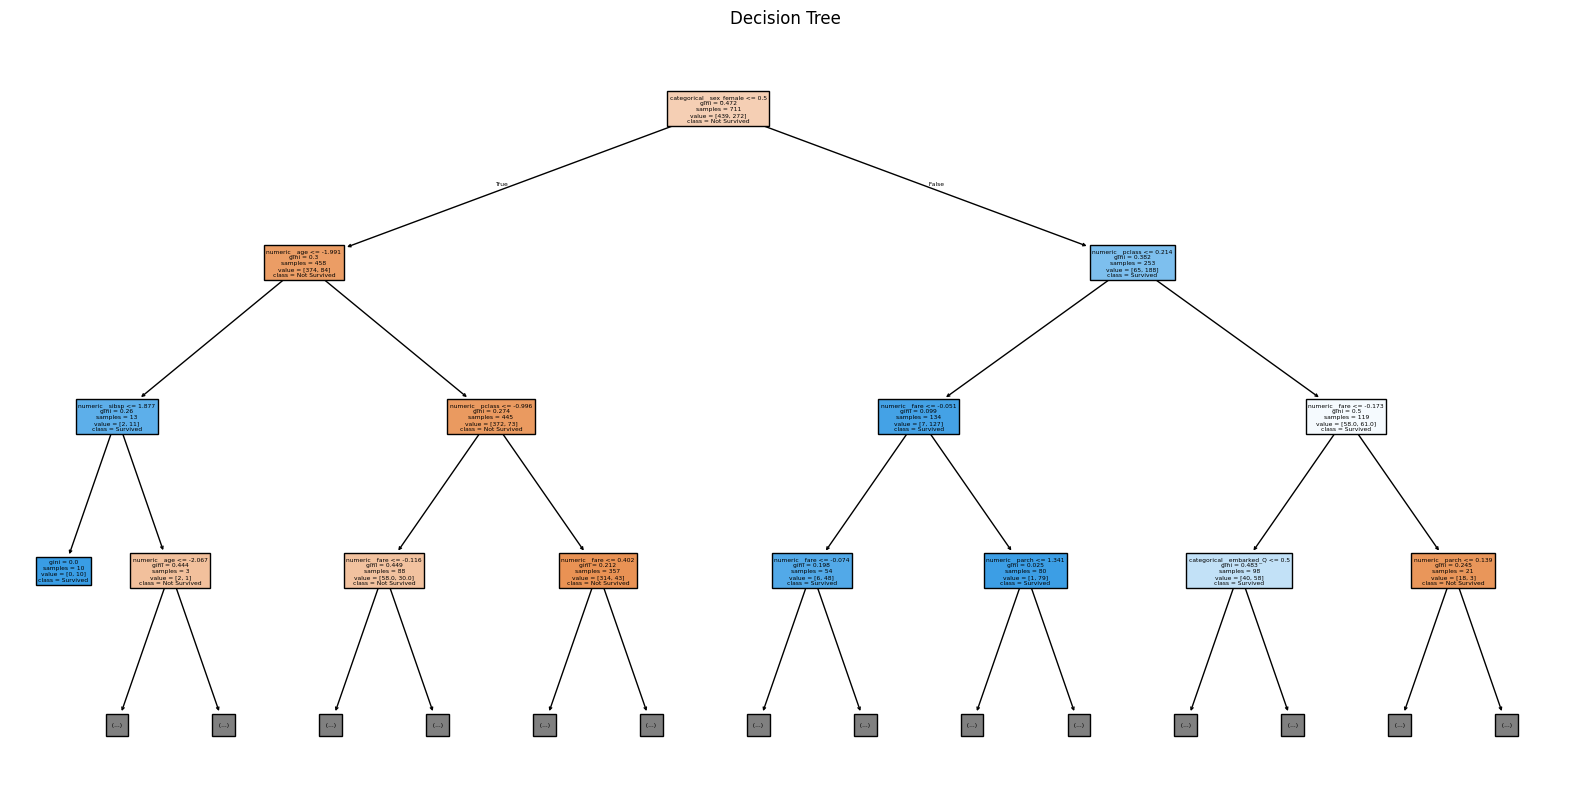

Tuned Random Forest
Confusion Matrix:
[[103   7]
 [ 23  45]]
Accuracy: 0.8314606741573034
Precision: 0.8653846153846154
Recall: 0.6617647058823529
F1: 0.75
AUC: 0.838903743315508
                 Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.808989   0.783333  0.691176  0.734375  0.860963
1        Decision Tree  0.769663   0.690141  0.720588  0.705036  0.754144
2        Random Forest  0.831461   0.865385  0.661765  0.750000  0.838904
Complete pipeline saved successfully.
                 Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.808989   0.783333  0.691176  0.734375  0.860963
1        Decision Tree  0.769663   0.690141  0.720588  0.705036  0.754144
2  Tuned Random Forest  0.831461   0.865385  0.661765  0.750000  0.838904
               Model        MAE       RMSE        R2  Adjusted R2
0  Linear Regression  18.373542  41.292124  0.360916     0.255804
Raw input:
   pclass     sex  age  sibsp  parch  fare embar

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

df_model = pd.read_csv("titanic.csv")
X = df_model[["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]]
y = df_model["survived"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining class percentage:")
print(y_train.value_counts(normalize=True))

print("\nTesting class percentage:")
print(y_test.value_counts(normalize=True))

numeric_features = ["pclass","age","sibsp","parch","fare"]
categorical_features = ["sex","embarked"]
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)])
print("Preprocessor created successfully.")

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))])
logistic_pipeline.fit(X_train, y_train)
print("Logistic Regression trained successfully.")

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))])
decision_tree_pipeline.fit(X_train, y_train)
print("Decision Tree trained successfully.")

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))])
random_forest_pipeline.fit(X_train, y_train)
print("Random Forest trained successfully.")

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_curve,roc_auc_score)

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

    print("\n", name)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]
)

print("\nModel Comparison:")
print(comparison_df)

plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, f1_score

baseline_model = LogisticRegression(max_iter=1000)
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", baseline_model)
])
baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)
baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", balanced_model)
])
balanced_pipeline.fit(X_train, y_train)
balanced_pred = balanced_pipeline.predict(X_test)
balanced_precision = precision_score(y_test, balanced_pred)
balanced_recall = recall_score(y_test, balanced_pred)
balanced_f1 = f1_score(y_test, balanced_pred)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)
smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_train_smote,y_train_smote)
smote_pred = smote_model.predict(X_test_processed)
smote_precision = precision_score(y_test, smote_pred)
smote_recall = recall_score(y_test, smote_pred)
smote_f1 = f1_score(y_test, smote_pred)

print("Baseline:")
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1:", baseline_f1)

print("\nClass Weight Balanced:")
print("Precision:", balanced_precision)
print("Recall:", balanced_recall)
print("F1:", balanced_f1)

print("\nSMOTE:")
print("Precision:", smote_precision)
print("Recall:", smote_recall)
print("F1:", smote_f1)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    oob_score=True)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf)])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Best parameters:")
print(grid_search.best_params_)
print("\nBest CV score:")
print(grid_search.best_score_)

best_pipeline = grid_search.best_estimator_
best_rf = best_pipeline.named_steps["model"]
print("OOB Score:", best_rf.oob_score_)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_reg = pd.read_csv("titanic.csv")
X_reg = df_reg.drop(columns=["fare"])
y_reg = df_reg["fare"]

numeric_features_reg = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]

categorical_features_reg = [
    "sex",
    "embarked",
    "class",
    "who",
    "adult_male",
    "embark_town",
    "alive",
    "alone"
]

numeric_pipeline_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_reg = ColumnTransformer([
    ("numeric", numeric_pipeline_reg, numeric_features_reg),
    ("categorical", categorical_pipeline_reg, categorical_features_reg)
])
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42)
reg_pipeline = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("model", LinearRegression())])
reg_pipeline.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_pipeline.predict(X_test_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = mean_squared_error(y_test_reg, y_pred_reg) ** 0.5
r2 = r2_score(y_test_reg, y_pred_reg)
n = len(y_test_reg)
p = len(
    reg_pipeline.named_steps["preprocessor"]
    .get_feature_names_out())
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_reg, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

from sklearn.tree import plot_tree
tree_model = decision_tree_pipeline.named_steps["model"]
feature_names = (
    decision_tree_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3
)
plt.title("Decision Tree")
plt.show()

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

best_pred = best_pipeline.predict(X_test)
best_prob = best_pipeline.predict_proba(X_test)[:, 1]

best_accuracy = accuracy_score(y_test, best_pred)
best_precision = precision_score(y_test, best_pred)
best_recall = recall_score(y_test, best_pred)
best_f1 = f1_score(y_test, best_pred)
best_auc = roc_auc_score(y_test, best_prob)

print("Tuned Random Forest")
print("Confusion Matrix:")
print(confusion_matrix(y_test, best_pred))
print("Accuracy:", best_accuracy)
print("Precision:", best_precision)
print("Recall:", best_recall)
print("F1:", best_f1)
print("AUC:", best_auc)

final_classification = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.808989,
        "Precision": 0.783333,
        "Recall": 0.691176,
        "F1": 0.734375,
        "AUC": 0.860963
    },
    {
        "Model": "Decision Tree",
        "Accuracy": 0.769663,
        "Precision": 0.690141,
        "Recall": 0.720588,
        "F1": 0.705036,
        "AUC": 0.754144
    },
    {
        "Model": "Random Forest",
        "Accuracy": best_accuracy,
        "Precision": best_precision,
        "Recall": best_recall,
        "F1": best_f1,
        "AUC": best_auc
    }
])
print(final_classification)

import joblib
joblib.dump(
    best_pipeline,
    "best_pipeline.joblib"
)
print("Complete pipeline saved successfully.")

final_table = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.808989,
        "Precision": 0.783333,
        "Recall": 0.691176,
        "F1": 0.734375,
        "AUC": 0.860963
    },
    {
        "Model": "Decision Tree",
        "Accuracy": 0.769663,
        "Precision": 0.690141,
        "Recall": 0.720588,
        "F1": 0.705036,
        "AUC": 0.754144
    },
    {
        "Model": "Tuned Random Forest",
        "Accuracy": 0.831461,
        "Precision": 0.865385,
        "Recall": 0.661765,
        "F1": 0.750000,
        "AUC": 0.838904
    }
])
print(final_table)
regression_table = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": 18.373542,
        "RMSE": 41.292124,
        "R2": 0.360916,
        "Adjusted R2": 0.255804
    }
])
print(regression_table)

import joblib

loaded_pipeline = joblib.load("best_pipeline.joblib")

raw_input = pd.DataFrame({
    "pclass": [1],
    "sex": ["female"],
    "age": [30],
    "sibsp": [0],
    "parch": [0],
    "fare": [75],
    "embarked": ["S"]
})

prediction = loaded_pipeline.predict(raw_input)
print("Raw input:")
print(raw_input)
print("\nPrediction:")
print(prediction)

if prediction[0] == 1:
    print("Predicted: Survived")
else:
    print("Predicted: Not Survived")